<a href="https://colab.research.google.com/github/lmendezayl/uba-optimizacion-tp1/blob/main/tp1_optimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales: Aplicacion del Metodo de Descenso por Gradiente

Para esta primera parte trabajaremos con el archivo `utils_tools.jl`, el dataset `Iris` y seguiremos los lineamientos vistos aquı. Utilizaremos una red con tres capas (con funciones de activacion ReLu, identidad y softmax) de 5 niveles.

In [1]:
import Pkg; Pkg.add("RDatasets")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Mocking ─────────── v0.8.1
   Installed TZJData ─────────── v1.5.0+2025b
   Installed CategoricalArrays ─ v1.1.0
   Installed TimeZones ───────── v1.22.2
   Installed RData ───────────── v1.1.0
   Installed RDatasets ───────── v0.8.1
  Installing 1 artifacts
   Installed artifact tzjdata                  112.5 KiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [ce6b1742] + RDatasets v0.8.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [324d7699] + CategoricalArrays v1.1.0
  [78c3b35d] + Mocking v0.8.1
  [df47a6cb] + RData v1.1.0
  [ce6b1742] + RDatasets v0.8.1
  [dc5dba14] + TZJData v1.5.0+2025b
  [f269a46b] + TimeZones v1.22.2
Precompiling packages...
   4685.8 ms  ✓ TZJData
   4347.3 ms  ✓ Mocking
   7328.4 ms  ✓ CategoricalArrays
   3232.5 ms  ✓ CategoricalArrays → CategoricalArraysJSONExt
   4339.5 ms  ✓ CategoricalArrays → CategoricalArraysStatsBaseExt


In [28]:
using LinearAlgebra, RDatasets, Random, Statistics, Plots, Printf

In [29]:
iris = dataset("datasets", "iris")
X = Matrix(iris[:, 1:4])
y = iris.Species

150-element CategoricalArrays.CategoricalArray{String,1,UInt8}:
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 ⋮
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"

In [30]:
# utils_tools.jl
function split(X, y; dims=1, ratio_train=0.8)
    n = length(y)

    n_train = round(Int, ratio_train*n) # Redondeamos el corte
    i_rand = randperm(n)				# Permutamos los indices
    i_train = i_rand[1:n_train] 		# Usamos el 80% para train
    i_test = i_rand[n_train+1:end] 		# El resto lo usamos para test

    X_train = X[i_train,:]
    y_train = y[i_train]
    X_test  = X[i_test, :]
    y_test  = y[i_test]
    return X_train, y_train, X_test, y_test

end

function normalize(X_train, X_test; dims=1)
    col_mean = mean(X_train; dims)
    col_std = std(X_train; dims)

    return (X_train .- col_mean) ./ col_std, (X_test .- col_mean) ./ col_std
end

function onehot(y, classes)
	y_onehot = zeros(length(classes), length(y))
	num_of_class = 1:length(classes)

	for i in 1:length(y)
		y_onehot[:,i] = y[i].==classes
	end
	return y_onehot
end

function prepare_data(X, y; do_normal=true, do_onehot=true, kwargs...)
    X_train, y_train, X_test, y_test = split(X, y)

    if do_normal
        X_train, X_test = normalize(X_train, X_test; kwargs...)
    end

    classes = unique(y)

    if do_onehot
        y_train = onehot(y_train, classes)
        y_test = onehot(y_test, classes)
    end

    return X_train', y_train, X_test', y_test, classes
end

X_train, y_train, X_test, y_test, classes = prepare_data(X, y)

mean_tuple(d::AbstractArray{<:Tuple}) = Tuple([mean([d[k][i] for k in 1:length(d)]) for i in 1:length(d[1])])

grad_total(modelo,grad,x,y) = mean_tuple([grad(modelo, X_train[:,k], y_train[:,k]) for k in 1:size(X_train,2)])

# funciones de activacion
relu(x) = max.(0,x)
id(x) = x
softmax(x) = exp.(x) ./ sum(exp.(x), dims=1)

softmax (generic function with 1 method)

In [31]:
println(size(X_train, 1))
println(size(X_train, 2))
println(size(y_train, 1))
println(size(y_train, 2))

4
120
3
120


In [32]:
mutable struct RedNeuronal{T<:Real}
	# Utilizaremos una red neuronal con tres capas con funciones de activacion ReLU,
	# identidad y softmax de 5 niveles.
	#
	# Nota: no es como Python, no hace falta definir una clase, ni tapoco
	# hace falta definir atributos como __init__ para poder definir el llamado a
	# el constructor de esta clase. Aca directamente llamamos
	# m = RedNeuronal(W1, b1, W2, b2)
	# y listo, con esto es suficiente para crear el modelo.
	#
	# El downside es que no podemos crear metodos bajo el struct RedNeuronal
	W1::Matrix{T} # l1 -> l2
	b1::Vector{T}
	W2::Matrix{T} # l2 -> l3
	b2::Vector{T}
end

# creamos el modelo con el constructor de Red Neuronal
Random.seed!(73)
W1 = randn(5, size(X_train, 1)) # este 1 era un 2, tomando una matriz de 5x4 enlugar de 5x120!
b1 = randn(5)
W2 = randn(size(y_train, 1), 5)
b2 = randn(size(y_train, 1 ))

model = RedNeuronal(W1, b1, W2, b2)

RedNeuronal{Float64}([1.2123689466501288 -1.8659948470385643 1.5359646820970976 -2.946693261135319; 0.07867339151355215 -0.5409383051722126 1.904244155888974 0.4000651169550351; … ; -1.4081384368973173 0.3566138060639536 0.758845608555424 -0.2462781339520417; 0.4644730607385192 -0.4580210630616379 -2.3363570247525765 0.6032439841236702], [0.036509117320801934, 2.0183941863348958, -1.4222121770628655, -0.02458224672669713, 0.5662594627526059], [0.9865857065343743 0.5569751877519062 … -0.013964807677120253 -1.1131349472530667; 0.5499123327973198 0.12834599681305806 … -0.7764680654747667 0.36181588423766176; -0.7411473285232308 -0.06050648910140387 … -0.7658544536287244 2.1530628891736723], [-0.14226841165752968, -1.0368122047759714, -0.14131008223303249])

## Ejercicio 1
Implementar una función `forward_pass(model,x)` que para cada dato $x$ retorne la predicción según el modelo.

In [33]:
function forward_pass(model, X) # Done
	# Implementar una funcion que para cada dato x retorne la prediccion segun
	# el modelo.
	W1, b1, W2, b2 = model.W1, model.b1, model.W2, model.b2
	z_1 = W1 * X .+ b1
	size(z_1)
	a_1 = relu(z_1)
	z_2 = W2 * a_1 .+ b2
	a_2 = z_2
	y = softmax(a_2)
	return y
end

forward_pass (generic function with 1 method)

In [34]:
# Evaluamos la salida del modelo para el primer dato
forward_pass(model, X_train[:,1])

3-element Vector{Float64}:
 0.0032544112636890524
 0.011378176140654069
 0.9853674125956569

In [35]:
# Evaluamos la salida del modelo para los 120 datos, viene en forma de matriz
forward_pass(model, X_train)

3×120 Matrix{Float64}:
 0.00325441  0.0036817  0.00122664  …  0.893752   0.788135   0.871791
 0.0113782   0.0110235  0.00492777     0.0521262  0.0789736  0.0604587
 0.985367    0.985295   0.993846       0.0541215  0.132891   0.06775

## Ejercicio 2
Implementar una función `grad(model,x,y)` que calcule el gradiente de la función de pérdida para cada par de datos $(x,y)$ utilizando $\texttt{back-propagation}$. Y utilizarla para calcular el gradiente completo usando la función `grad_total` de `utils_tools.jl`.

In [36]:
function grad(model, X, y)
    # Implementar una funcion que calcule el gradiente de la funcion de perdida para
    # cada par de datos (x,y) utilizando backprop. Usarla para calcular el grad completo
    # usando la funcion grad_total de utils_tools.jl

    # Obtenemos los datos del modelo
    W1, b1, W2, b2 = model.W1, model.b1, model.W2, model.b2

    # Hacemos el forward pass
    z_1 = W1 * X .+ b1
    a_1 = relu.(z_1)
    z_2 = W2 * a_1 .+ b2
    y_pred = softmax(z_2)

    # Definimos la derivada de la relu
    relu_prime(X) = X > 0 ? 1.0 : 0.0 # heaviside = relu'

    delta_2 = y_pred .- y # https://eli.thegreenplace.net/2016/the-softmax-function-and-its-derivative/
    grad_W2 = delta_2 * a_1'
    grad_b2 = delta_2
    delta_1 = (W2' * delta_2) .* relu_prime.(z_1) # .* es prod de hadamard
    grad_W1 = delta_1 * X'
    grad_b1 = delta_1
    return (grad_W1, grad_b1, grad_W2, grad_b2)
end

grad (generic function with 1 method)

In [37]:
grad(model, X_train, y_train)

([50.90074841657719 -19.05532362547675 50.1869189016502 40.82999000779878; 23.721769458380948 -12.29968383317684 27.25152568841257 26.435698656354884; … ; 25.257401972085287 -35.793332054327934 41.840681655557596 40.3680499251332; -142.59442617977325 147.08908015652608 -185.62369576305738 -182.9876485838109], [-0.0 -1.7071400968677202 … 0.0 0.0; -0.0 -0.0 … 0.5015735456541892 0.5497329054389402; … ; -0.7495634513638408 -0.7492384146442187 … 0.0 0.0; 3.2351871614648537 3.2344269399788166 … -2.715667429907575 -0.0], [74.59015870788936 267.1543202660896 … -34.88329765445351 -62.29086604322757; -57.27517001404486 -107.81747458575322 … -6.0865622500431495 -15.583810629308571; -17.31498869384455 -159.3368456803364 … 40.969859904496644 77.87467667253613], [-0.9967455887363109 -0.9963183027218414 … 0.78813543483303 0.8717912553442528; 0.011378176140654082 0.011023462821827854 … 0.07897357397102196 0.06045871817694882; 0.9853674125956569 0.9852948399000135 … -0.867109008804052 -0.93224997352120

## Ejercicio 3
Implementar una función `train!` que tome como parámetros, el modelo a entrenar, los conjuntos de entrenamiento, el tamaño del paso y la cantidad de iteraciones máximas para entrenar la red utilizando el método de descenso por gradiente con paso constante. La función debe retornar el modelo entrenado y un vector con los valores de la función de pérdida en cada iteración.

*Opcional:* Probar distintas funciones de activación y comparar.

In [38]:
println(size(y_train))

(3, 120)


In [39]:
function train!(model, X_train, y_train, step=1e-2, max_iter=10000)
	# La funcion debe retornar el modelo entrenado y un vector con los valores de la
	# funcion de perdida en cada iteracion
	loss_hist = []
	cross_entropy(y_pred) = -mean(sum(y_train .* log.(y_pred), dims=1))

	for i in 1:max_iter
		# begin iter
		# correr forward pass -> y
		# calcular cross entropy -> loss
		# hacer backprop -> delta_C
		# actualizar? preguntar
		# end iter
		y_pred = forward_pass(model, X_train)
		loss = cross_entropy(y_pred)
		push!(loss_hist, loss)
		grad_W1, grad_b1, grad_W2, grad_b2 = grad_total(model, grad, X_train, y_train)
		model.W1 .-= step .* grad_W1
		model.b1 .-= step .* grad_b1
		model.W2 .-= step .* grad_W2
		model.b2 .-= step .* grad_b2

		if i % (max_iter/10) == 0 || i == 1
    	println("Iteración $i | Loss: $loss")
    end

	end

	return model, loss_hist
end

train! (generic function with 3 methods)

## Ejercicio 4
Implementar una función `results` que retorne el gráfico de los valores de la función de pérdida para cada iteración y el rendimiento de nuestro modelo tanto en los conjuntos de entrenamiento como en los de prueba, por ejemplo, calculando $\frac{\#favorables}{\#casos\_totales}$

In [40]:
function results(model, X_train, y_train, X_test, y_test; step=1e-2, max_iter=10000)

	model, loss_hist = train!(model, X_train, y_train, step, max_iter)

	# hacer la funcion que convierta y_pred a matriz de 1s y 0s
	# tal que valga 1 en la proba mas grande y 0 en las otras dos
	# por sample , talque podamos hacer #correctos/#total
	# supongamos que devuelve y_pred_bin

	# Convertimos las probabilidades a one-hot: 1 para de mayor valor y 0 al resto.
	onehot_pred(y_pred) = Float64.(y_pred .== maximum(y_pred, dims=1))

	y_pred_train = onehot_pred(forward_pass(model, X_train))
	y_pred_test = onehot_pred(forward_pass(model, X_test))

	# La accuracy: sumamos 1 si le pegamos, 0 si no y promediamos
	accuracy_train = mean(all(y_pred_train .== y_train, dims=1))
	accuracy_test = mean(all(y_pred_test .== y_test, dims=1))

	println("Accuracy train: $(round(accuracy_train*100, digits=2))%")
  println("Accuracy test:  $(round(accuracy_test*100,  digits=2))%")

	return plot(loss_hist, xlabel="Iteración", ylabel="Loss", title="Curva de pérdida", label="cross-entropy")

end

results (generic function with 1 method)

Iteración 1 | Loss: 4.055270694500624
Iteración 1000 | Loss: 0.2315772983054261
Iteración 2000 | Loss: 0.16643672552753586
Iteración 3000 | Loss: 0.13105917599541156
Iteración 4000 | Loss: 0.11062708335874598
Iteración 5000 | Loss: 0.09787349036062118
Iteración 6000 | Loss: 0.08847059575582504
Iteración 7000 | Loss: 0.08097137644859037
Iteración 8000 | Loss: 0.07482018465666034
Iteración 9000 | Loss: 0.06945312441908902
Iteración 10000 | Loss: 0.0646610828563879
Accuracy train: 98.33%
Accuracy test:  90.0%


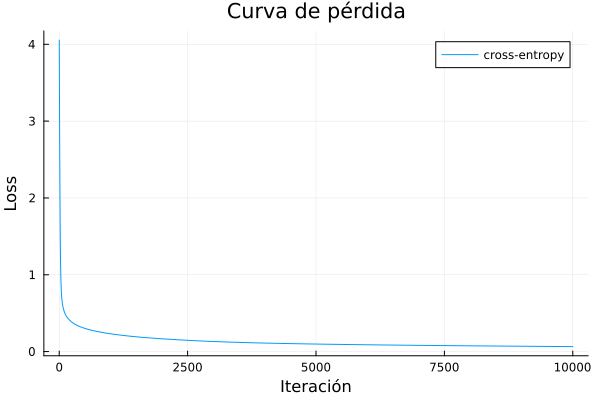

In [41]:
results(model, X_train, y_train, X_test, y_test, max_iter=10000)

# Perfil de desempeño

## Ejercicio 5
Implementar los siguientes métodos de descenso
* Gradiente con paso constante
* Gradiente con búsqueda de línea (condición de Armijo)
* Método de Newton
* Gradiente Conjugado No-Lineal (Fletcher-Reeves) y/o Método quasi-Newton BFGS

Cada método debe retornar: Estado (Convergió, máximas iteraciones alcanzadas, no convergió), número de iteraciones realizadas y valor final de $\|\nabla f\|$.

In [42]:
function gradiente_const(f, ∇f, x0; α = 0.01, tol = 1e-6, max_iter = 10000)
  # f es la función a minimizar, con ∇f su gradiente y x0 el vector inicial, con α el tamaño del paso
  x = copy(x0)

  for k in 1:max_iter
    g = ∇f(x)
    gnorm = norm(g)

    # Criterio de convergencia
    if gnorm < tol
      return ("Convergió", k, gnorm, x)
    end

    # Paso de gradiente con paso constante
    x_new = x - α .* g

    # Chequeamos si alguna de las coordenadas no es finita
    if any(!isfinite, x_new)
      return ("No convergió", k, gnorm, x)
    end

    x = x_new
  end

  gnorm = norm(∇f(x))
  return("Máximas iteraciones alcanzadas", k, gnorm, x)
end


gradiente_const (generic function with 1 method)

In [43]:
function gradiente_armijo(f, ∇f, x0; α0 = 1, δ=1e-4, ρ = 0.5, tol=1e-6, max_iter=10000)
  # f es la función a minimizar, con ∇f su gradiente y x0 el vector inicial
  # α0 es el tamaño de paso inicial, siendo δ el parámetro Armijo y ρ el parámetro de reducción
  x = copy(x0)

  for k in 1:max_iter
    g = ∇f(x)
    gnorm = norm(g)

    # Criterio de convergencia
    if gnorm < tol
      return ("Convergió", k, gnorm, x)
    end

    # Reducimos α hasta cumplir la condición de Armijo
    α = α0
    fx = f(x)
    while f(x - α .* g) > fx - δ * α * gnorm^2
      α = ρ * α

      # Si el α se vuelve demasiado pequeño, hubo algún problema
      if α < 1e-16
        return ("No convergió", k, gnorm, x)
      end
    end

    x_new = x - α .* g

    # Chequeamos si alguna de las coordenadas no es finita
    if any(!isfinite, x_new)
      return ("No convergió", k, gnorm, x)
    end

    x = x_new
  end

  gnorm = norm(∇f(x))
  return("Máximas iteraciones alcanzadas", k, gnorm, x)
end

gradiente_armijo (generic function with 1 method)

In [57]:
function newton_raphson(f, ∇f, Hf, x0; tol=1e-6, max_iter=1000)
  # f es la función a minimizar, con ∇f su gradiente, Hf su hessiano y x0 el vector inicial
  x = copy(x0)

  for k in 1:max_iter
    g = ∇f(x)
    gnorm = norm(g)

    if gnorm < tol
      return ("Convergió", k, gnorm, x)
    end

    H = Hf(x)

    # Sabemos que el paso debería ser x_{k+1} = x_k - [Hf(x_k)]^{-1} ∇f(x_k), pero no queremos hallar la inversa
    # así que resolvemos Hf(x_k) d_k = ∇f(x_k) y hacemos el paso como x_{k+1} = x_k - d_k

    # Intentamos construir d_k como mencionamos, si falla es porque el hessiano es singular
    d = try
      H \ g
    catch
      return ("No convergió (H es singular)", k, gnorm, x)
    end

    # Verificamos que la dirección obtenida es de descenso
    if dot(g, d) > 0
      return ("No convergió (d no es una dirección de descenso)", k, gnorm, x)
    end

    # Efectuamos el paso
    x_new = x - d

    # Chequeamos si alguna de las coordenadas no es finita
    if any(!isfinite, x_new)
      return ("No convergió (Divergió)", k, gnorm, x)
    end

    x = x_new
  end

  gnorm = norm(∇f(x))
  return ("Máximas iteraciones alcanzadas", max_iter, gnorm, x)
end

newton_raphson (generic function with 1 method)

In [58]:
# Página 120 del Nocedal
function fletcher_reeves(f, ∇f, x0; α0=1.0, c1=1e-4, c2 = 0.4, ρ=0.5, tol=1e-6, max_iter=10000)
  x = copy(x0)
  g = ∇f(x0)

  # La dirección inicial es la opuesta al gradiente
  d = -g

  for k in 1:max_iter
    gnorm = norm(g)

    if gnorm < tol
      return ("Convergió", k, gnorm, x)
    end

    # Búsqueda utilizando las condiciones de Wolfe fuertes
    α = α0
    fx = f(x)
    dg = dot(g,d)
    g_new = g

    for _ in 1:100
      x_new = x + α .* d
      f_new = f(x_new)
      g_new = ∇f(x_new)

      if f_new > fx + c1 * α * dg
        α = ρ * α
      elseif abs(dot(g_new, d)) <= c2 * abs(dg)
          break
      else
          α = α / ρ
      end
    end

    if α < 1e-16
      return ("No convergió", k, gnorm, x)
    end

    x_new = x + α .* d
    g_new = ∇f(x_new)

    β = dot(g_new, g_new) / dot(g, g)

    # https://link.springer.com/article/10.1007/BF01593790
    # Analizar si dejar o no este proceso llamado "reinicio".
    if k % length(x) == 0
       d = -g_new
    else
      d = -g_new + β .* d
    end

    x = x_new
    g = g_new
    gnorm = norm(g)
  end

  return ("Máximas iteraciones alcanzadas", max_iter, gnorm, x)

end

fletcher_reeves (generic function with 1 method)

In [46]:
# Página 198 del Nocedal
function bfgs(f, ∇f, x0; tol=1e-6, max_iter=10000, s=1.0, c1=1e-4, c2=0.9)
    n = length(x0)
    x = copy(x0)
    g = ∇f(x)
    B = I(n) * 1.0  # aproximación inicial de H⁻¹: identidad

    for k in 1:max_iter
        gnorm = norm(g)

        if gnorm < tol
            return ("Convergió", k, gnorm, x)
        end

        # Dirección de búsqueda
        d = -B * g

        # Búsqueda de línea con Wolfe fuerte
        α  = s
        fx = f(x)
        dg = dot(g, d)
        g_new = g

        for _ in 1:100
            x_new  = x + α .* d
            f_new  = f(x_new)
            g_new  = ∇f(x_new)

            if f_new > fx + c1 * α * dg
                α *= 0.5
            elseif abs(dot(g_new, d)) <= c2 * abs(dg)
                break
            else
                α *= 2.0
            end
        end

        if α < 1e-16
            return ("No convergió", k, gnorm, x)
        end

        x_new = x + α .* d
        g_new = ∇f(x_new)

        # Vectores de actualización
        s_k = x_new - x
        y_k = g_new - g

        ρ_k = dot(y_k, s_k)

        # Si ρ_k ≤ 0 la actualización no sería definida positiva, saltamos
        if ρ_k <= 0
            x = x_new
            g = g_new
            continue
        end

        ρ_k = 1.0 / ρ_k

        # Actualización BFGS de la inversa de la hessiana
        B = (I - ρ_k * s_k * y_k') * B * (I - ρ_k * y_k * s_k') + ρ_k * s_k * s_k'

        x = x_new
        g = g_new
    end

    return ("Máximas iteraciones alcanzadas", max_iter, norm(∇f(x)), x)
end

bfgs (generic function with 1 method)

## Ejercicio 6
Utilizar cada método con las funciones incluidas en el archivo `benchmark.jl`

In [50]:
include("benchmarks.jl")

froth_h (generic function with 1 method)

In [51]:
# Configuramos previamente las funciones benchmark para que sean aceptadas por nuestros métodos
benchmarks = [
    (
        name = "Sphere (n=2)",
        f    = sphere,
        ∇f   = sphere_g,
        Hf   = sphere_h,
        x0   = [3.0, 4.0]
    ),
    (
        name = "Rosenbrock",
        f    = rosenbrock,
        ∇f   = rosenbrock_g,
        Hf   = rosenbrock_h,
        x0   = [-1.0, 1.0]
    ),
    (
        name = "Rastrigin (n=2)",
        f    = rastrigin,
        ∇f   = rastrigin_g,
        Hf   = rastrigin_h,
        x0   = [0.5, 0.5]
    ),
    (
        name = "Wood (n=4)",
        f    = wood,
        ∇f   = wood_g,
        Hf   = wood_h,
        x0   = [-3.0, -1.0, -3.0, -1.0]
    ),
    (
        name = "Freudenstein-Roth",
        f    = froth,
        ∇f   = froth_g,
        Hf   = froth_h,
        x0   = [0.5, -2.0]
    ),
]

5-element Vector{NamedTuple{(:name, :f, :∇f, :Hf, :x0)}}:
 (name = "Sphere (n=2)", f = Main.sphere, ∇f = Main.sphere_g, Hf = Main.sphere_h, x0 = [3.0, 4.0])
 (name = "Rosenbrock", f = Main.rosenbrock, ∇f = Main.rosenbrock_g, Hf = Main.rosenbrock_h, x0 = [-1.0, 1.0])
 (name = "Rastrigin (n=2)", f = Main.rastrigin, ∇f = Main.rastrigin_g, Hf = Main.rastrigin_h, x0 = [0.5, 0.5])
 (name = "Wood (n=4)", f = Main.wood, ∇f = Main.wood_g, Hf = Main.wood_h, x0 = [-3.0, -1.0, -3.0, -1.0])
 (name = "Freudenstein-Roth", f = Main.froth, ∇f = Main.froth_g, Hf = Main.froth_h, x0 = [0.5, -2.0])

In [52]:
# Usamos unos helpers para mejorar el formato de la respuesta
pad(s, n) = rpad(string(s), n)

function print_row(method, status, iters, gnorm, fx)
    println(
        "  ", pad(method, 22),
        pad(status, 32),
        pad(iters, 10),
        pad(@sprintf("%.2e", gnorm), 14),
        @sprintf("%.6f", fx)
    )
end

function print_header()
    println("  ", pad("Método", 22), pad("Estado", 32), pad("Iters", 10), pad("‖∇f‖", 14), "f(x*)")
    println("  " * "─"^88)
end

print_header (generic function with 1 method)

In [55]:
# Corremos todos los métodos bajo la misma función
function run_benchmark(b)
    println("\n" * "═"^92)
    println("  $(b.name)    x₀ = $(b.x0)")
    println("═"^92)
    print_header()

    # 1. Gradiente paso constante
    status, iters, gnorm, x = gradiente_const(b.f, b.∇f, b.x0; α=0.001)
    print_row("Paso constante", status, iters, gnorm, b.f(x))

    # 2. Armijo
    status, iters, gnorm, x = gradiente_armijo(b.f, b.∇f, b.x0)
    print_row("Armijo", status, iters, gnorm, b.f(x))

    # 3. Newton-Raphson
    status, iters, gnorm, x = newton_raphson(b.f, b.∇f, b.Hf, b.x0)
    print_row("Newton-Raphson", status, iters, gnorm, b.f(x))

    # 4. Fletcher-Reeves
    status, iters, gnorm, x = fletcher_reeves(b.f, b.∇f, b.x0)
    print_row("Fletcher-Reeves", status, iters, gnorm, b.f(x))

    # 5. BFGS
    status, iters, gnorm, x = bfgs(b.f, b.∇f, b.x0)
    print_row("BFGS", status, iters, gnorm, b.f(x))
end

run_benchmark (generic function with 1 method)

In [59]:
# Resultados
for b in benchmarks
    run_benchmark(b)
end

println("\n" * "═"^92)


════════════════════════════════════════════════════════════════════════════════════════════
  Sphere (n=2)    x₀ = [3.0, 4.0]
════════════════════════════════════════════════════════════════════════════════════════════
  Método                Estado                          Iters     ‖∇f‖          f(x*)
  ────────────────────────────────────────────────────────────────────────────────────────
  Paso constante        Convergió                       8052      1.00e-06      0.000000
  Armijo                Convergió                       2         0.00e+00      0.000000
  Newton-Raphson        No convergió (d no es una dirección de descenso)1         1.00e+01      25.000000
  Fletcher-Reeves       Convergió                       2         0.00e+00      0.000000
  BFGS                  Convergió                       2         0.00e+00      0.000000

════════════════════════════════════════════════════════════════════════════════════════════
  Rosenbrock    x₀ = [-1.0, 1.0]
═════════════

LoadError: UndefVarError: `k` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Ejercicio 7
Construir el Perfil de Desempeño de Dolan & Moré para la métrica de iteraciones. Graficar y realizar un breve análisis.

*Sugerencia:* El primer paso consiste en ejecutar cada uno de los algoritmos sobre cada problema y registrar el costo (iteraciones) de cada uno. Así, podemos formar la matriz $C$ de costos. Luego se puede calcular una matriz $R$ con la formula
$$r_{s,p} = \frac{c_{s,p}}{\min\{c_{j,p}: j \in S\}}$$

In [22]:
# TODO
function dolan_more()
	# construir perfil de desempeno de dolan & more para la metrica de iteraciones.
	# graficar y realizar un breve analisis.
	# sug: el primer paso consiste en ejecutar cada uno de los algoritmos sobre cada
	# problema y registrr el costo (iteraciones) de cada uno. Asi, podemos formar la
	# matriz C de costos. Luego se puede calcular una matriz R con la formula de r_sp
	# (ver clase de perfil de desempeno)
end

dolan_more (generic function with 1 method)